# Segmentacao de Imagens por Transformada de Watershed
**UFPI - Campus Senador Helvidio Nunes de Barros**  
**Disciplina:** Topicos Especiais em Visao Computacional - Prof. Jose Denes Lima Araujo  
**Grupo 4:** Segmentacao Baseada em Regiao (Secao 10.5 - Gonzalez & Woods)  
**Parte Pratica:** Integrante 3 (Analise Experimental)

---

### Objetivo
Demonstrar a aplicacao da Transformada de Watershed controlada por marcadores para segmentar objetos em contato (moedas sobrepostas), evidenciando a limitacao da limiarizacao global (Otsu) e a solucao via Transformada de Distancia Euclidiana.


In [8]:
# Instalacao das dependencias para execucao no Google Colab
!pip install -q opencv-python numpy matplotlib scikit-image scipy

In [9]:
# Importacao das bibliotecas necessarias
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuracao padrao de exibicao dos graficos
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Criacao dos diretorios de apoio caso nao existam
os.makedirs("imagens", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

# Caminho da imagem de teste (se nao estiver presente localmente, baixa automaticamente)
img_path = os.path.join("imagens", "moedas_sobrepostas.jpg")
if not os.path.exists(img_path):
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg"
    urllib.request.urlretrieve(url, img_path)
    print("Imagem baixada com sucesso:", img_path)
else:
    print("Imagem carregada localmente:", img_path)


Imagem carregada localmente: imagens/moedas_sobrepostas.jpg


### 1. Leitura e Preparacao da Imagem
A imagem contem moedas circulares sobre fundo claro, com diversos pontos de contato (tangencia).
Convertemos para tons de cinza para poder aplicar as operacoes morfologicas e de limiarizacao.


Dimensoes: 252x312 pixels, 3 canais.


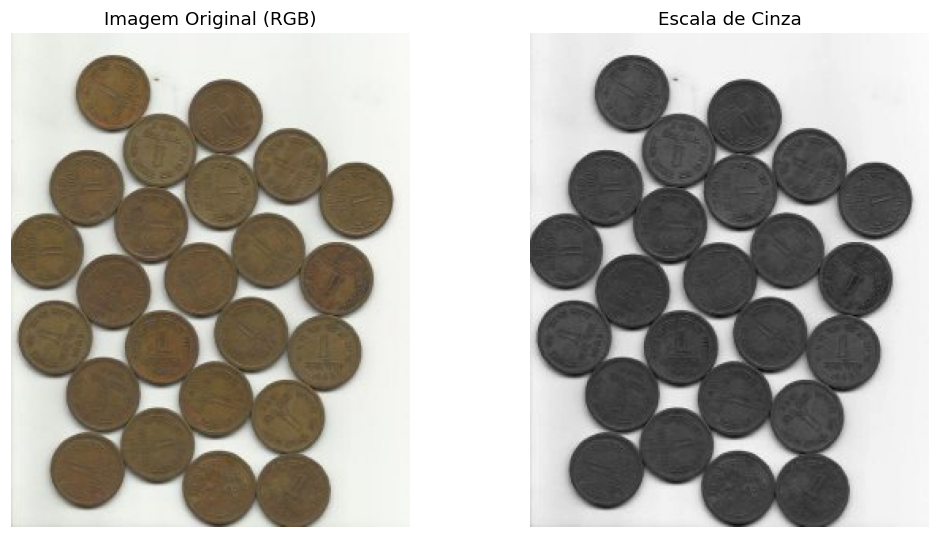

In [10]:
# Leitura no formato padrao BGR do OpenCV
img_bgr = cv2.imread(img_path)

# Conversao para RGB (para visualizacao correta no Matplotlib)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Conversao para tons de cinza (matriz 2D de intensidades de 0 a 255)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Dimensoes: {img_rgb.shape[1]}x{img_rgb.shape[0]} pixels, {img_rgb.shape[2]} canais.")

# Visualizacao lado a lado
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rgb)
ax[0].set_title("Imagem Original (RGB)")
ax[0].axis("off")

ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Escala de Cinza")
ax[1].axis("off")
plt.tight_layout()
plt.show()


### 2. Binarizacao de Otsu e Abertura Morfologica
A limiarizacao global de Otsu busca o valor de limiar que minimiza a variancia intra-classe.
Como as moedas sao escuras e o fundo e branco, usamos `THRESH_BINARY_INV` para que os objetos fiquem com valor 255 (branco) e o fundo com valor 0 (preto).
Em seguida, aplicamos uma abertura morfologica (erosao seguida de dilatacao com elemento estruturante 3x3) para eliminar pequenos ruidos pontuais.


Limiar de Otsu calculado: 162.0
Componentes conexos encontrados pelo Otsu puro: 1
Observacao: Otsu falha na separacao. Todas as moedas em contato foram fundidas em 1 unico bloco.


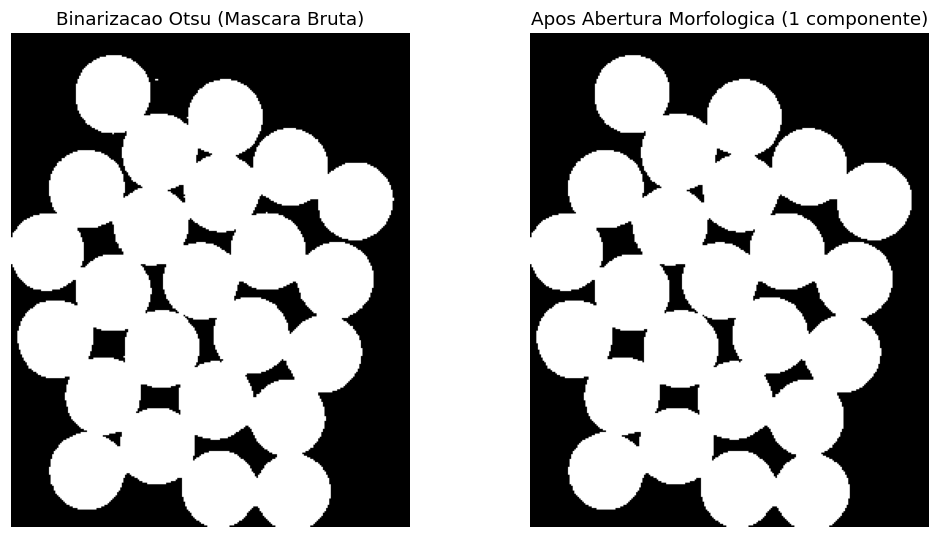

In [11]:
# Limiarizacao de Otsu invertida
# O valor 0 e ignorado pois cv2.THRESH_OTSU calcula o limiar ideal automaticamente
otsu_val, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Limiar de Otsu calculado: {otsu_val:.1f}")

# Elemento estruturante retangular 3x3
kernel = np.ones((3, 3), np.uint8)

# Abertura morfologica: remove pequenos ruidos espalhados na imagem
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Rotulacao de componentes conexos apenas na mascara binaria do Otsu
num_labels_otsu, _ = cv2.connectedComponents(opening)
qtd_otsu = num_labels_otsu - 1  # subtrai o fundo (rotulo 0)

print(f"Componentes conexos encontrados pelo Otsu puro: {qtd_otsu}")
if qtd_otsu == 1:
    print("Observacao: Otsu falha na separacao. Todas as moedas em contato foram fundidas em 1 unico bloco.")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(thresh, cmap="gray")
ax[0].set_title("Binarizacao Otsu (Mascara Bruta)")
ax[0].axis("off")

ax[1].imshow(opening, cmap="gray")
ax[1].set_title(f"Apos Abertura Morfologica ({qtd_otsu} componente)")
ax[1].axis("off")
plt.tight_layout()
plt.show()


### 3. Construcao dos Marcadores (Sure Background e Sure Foreground)
Para evitar a sobre-segmentacao (over-segmentation) inerente ao Watershed puro, criamos marcadores baseados em conhecimento geometrico:
1. **Fundo Seguro (`sure_bg`):** Dilatamos a mascara binaria. A regiao que permanece preta apos 3 dilatacoes e garantidamente fundo.
2. **Transformada de Distancia Euclidiana (`cv2.distanceTransform`):** Para cada pixel pertencente a uma moeda, calcula a menor distancia geometrica ate a borda mais proxima do fundo. Como as moedas sao circulares, os valores maximos de distancia ocorrem nos centros das moedas.
3. **Primeiro Plano Seguro (`sure_fg`):** Aplicamos um limiar nos picos da distancia (70% do valor maximo). As conexoes de toque entre as bordas possuem valores de distancia baixos e sao eliminadas, restando apenas os centros desconectados de cada moeda.
4. **Regiao Desconhecida (`unknown`):** Subtraindo o primeiro plano seguro do fundo seguro, obtemos a zona de fronteira e disputa onde o Watershed construira as barragens.


Distancia euclidiana maxima ao fundo: 23.97 pixels (raio interno medio das moedas)


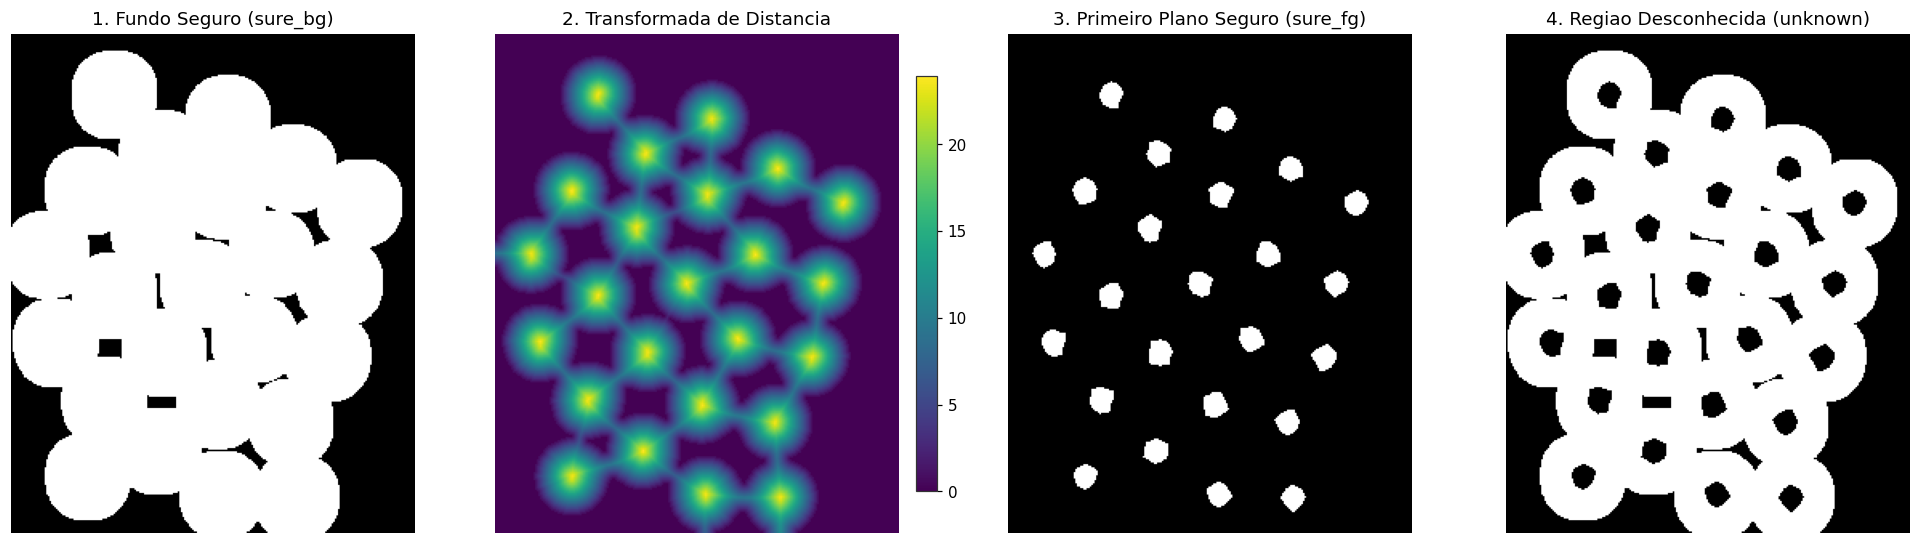

In [12]:
# 1. Fundo Seguro (Sure Background): dilatacao expande o objeto em direcao ao fundo
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 2. Transformada de Distancia Euclidiana (distancia L2 com mascara 5x5)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
max_dist = dist_transform.max()
print(f"Distancia euclidiana maxima ao fundo: {max_dist:.2f} pixels (raio interno medio das moedas)")

# 3. Primeiro Plano Seguro (Sure Foreground): limiar em 70% do pico maximo
limiar_dist = 0.7 * max_dist
_, sure_fg = cv2.threshold(dist_transform, limiar_dist, 255, 0)
sure_fg = np.uint8(sure_fg)

# 4. Regiao Desconhecida: bordas e regioes de transicao entre fundo e centros
unknown = cv2.subtract(sure_bg, sure_fg)

# Visualizacao das 4 etapas
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(sure_bg, cmap="gray")
ax[0].set_title("1. Fundo Seguro (sure_bg)")
ax[0].axis("off")

im_dist = ax[1].imshow(dist_transform, cmap="viridis")
ax[1].set_title("2. Transformada de Distancia")
ax[1].axis("off")
plt.colorbar(im_dist, ax=ax[1], fraction=0.046, pad=0.04)

ax[2].imshow(sure_fg, cmap="gray")
ax[2].set_title("3. Primeiro Plano Seguro (sure_fg)")
ax[2].axis("off")

ax[3].imshow(unknown, cmap="gray")
ax[3].set_title("4. Regiao Desconhecida (unknown)")
ax[3].axis("off")

plt.tight_layout()
plt.show()


### 4. Rotulacao e Execucao da Transformada de Watershed
Preparamos a matriz de marcadores para o algoritmo:
- Usamos `cv2.connectedComponents` nas sementes centrais (`sure_fg`). Cada centro de moeda recebe um rotulo inteiro (1, 2, ..., N).
- Somamos 1 a todos os rotulos: `markers = markers + 1`. Isso e obrigatorio no OpenCV para que o fundo receba o rotulo 1 e os objetos comecem a partir do rotulo 2.
- Definimos a regiao desconhecida com rotulo 0: `markers[unknown == 255] = 0`. O Watershed simula a inundacao partindo dos marcadores e expandindo exclusivamente sobre os pixels de rotulo 0.
- Onde as bacias de duas moedas se encontram, o algoritmo ergue barragens de 1 pixel de espessura com valor -1.


Total de sementes (marcadores internos) identificadas: 24
Total de pixels que compoem as barragens divisórias: 3976


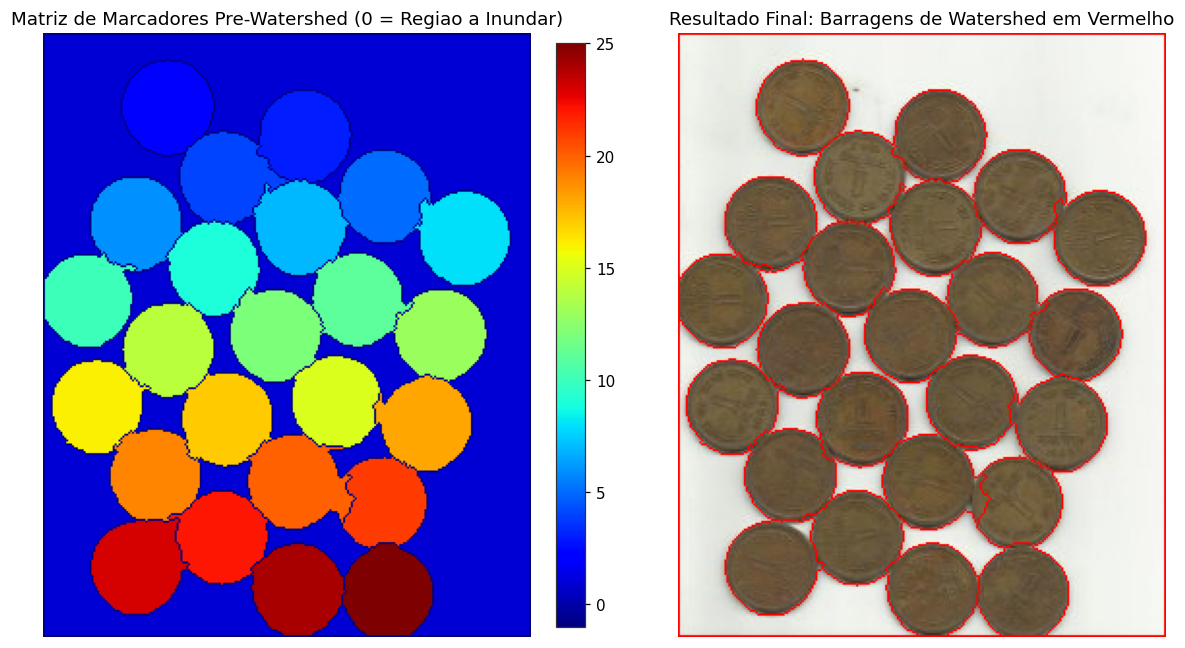

In [13]:
# Rotulacao conexa das sementes centrais
num_labels, markers = cv2.connectedComponents(sure_fg)
total_moedas = num_labels - 1
print(f"Total de sementes (marcadores internos) identificadas: {total_moedas}")

# Ajuste obrigatorio de rotulos para o OpenCV Watershed:
# Fundo definitivo passa a ser 1, objetos passam a ser de 2 a N+1
markers = markers + 1

# A regiao desconhecida recebe o rotulo 0 (area a ser inundada)
markers[unknown == 255] = 0

# Execucao do Watershed sobre a imagem colorida
img_watershed = img_rgb.copy()
markers_result = cv2.watershed(img_watershed, markers)

# As barragens construidas recebem rotulo -1. Destacamos em vermelho puro [255, 0, 0]
img_watershed[markers_result == -1] = [255, 0, 0]

qtd_barragens = np.sum(markers_result == -1)
print(f"Total de pixels que compoem as barragens divisórias: {qtd_barragens}")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im_m = ax[0].imshow(markers, cmap="jet")
ax[0].set_title("Matriz de Marcadores Pre-Watershed (0 = Regiao a Inundar)")
ax[0].axis("off")
plt.colorbar(im_m, ax=ax[0], fraction=0.046, pad=0.04)

ax[1].imshow(img_watershed)
ax[1].set_title("Resultado Final: Barragens de Watershed em Vermelho")
ax[1].axis("off")
plt.tight_layout()
plt.show()


### 5. Metrologia e Contagem Individual
Diferente de abordagens puramente estatisticas que geram nuvens dispersas de pontos, o Watershed entrega regioes conexas fechadas com rotulos individuais.
Isso permite extrair diretamente medidas de cada moeda: area em pixels e coordenadas do centroide cartesiano via momentos espaciais (`cv2.moments`).


Total de moedas individualizadas com sucesso: 24
Area media por moeda: 1725.1 pixels (Desvio padrao: 63.1 px)


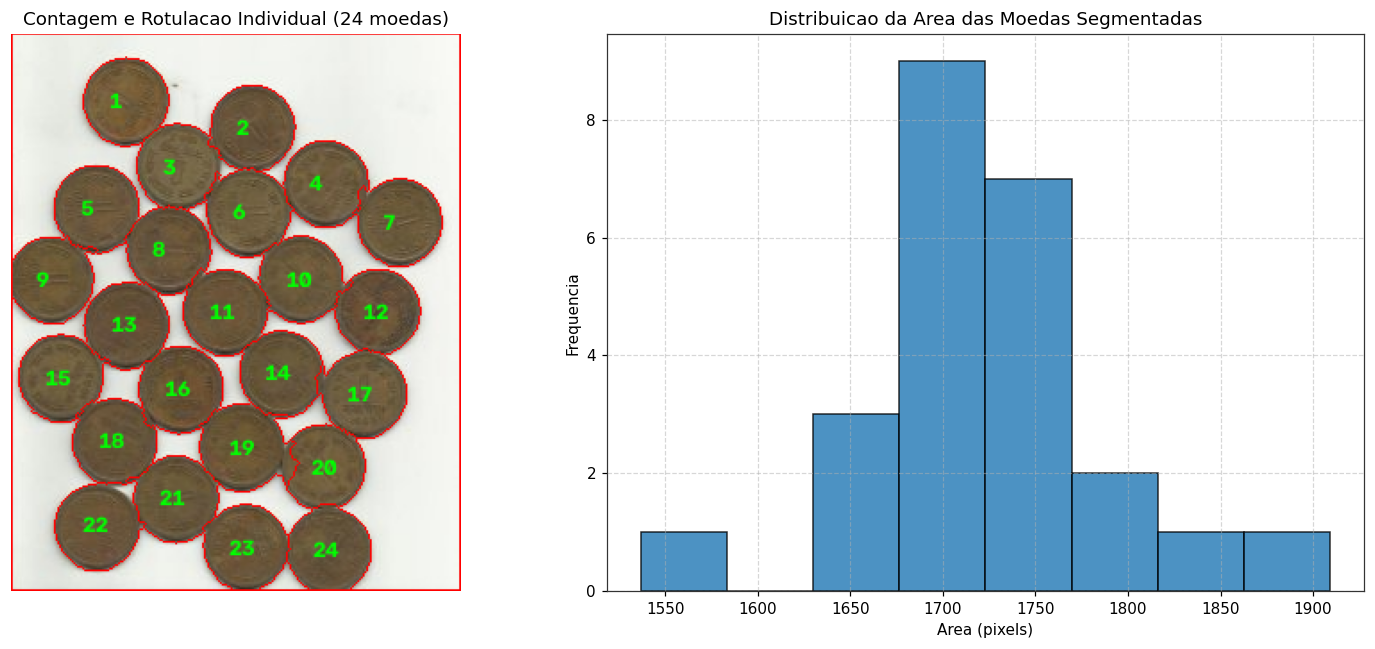

In [14]:
# Lista de rotulos validos (exclui fundo=1 e fronteiras=-1)
rotulos_validos = [lbl for lbl in np.unique(markers_result) if lbl > 1]

img_metrologia = img_rgb.copy()
areas = []

for idx, lbl in enumerate(rotulos_validos, 1):
    # Mascara binaria da moeda individual
    mascara = np.uint8(markers_result == lbl)
    
    # Area: soma dos pixels da mascara
    area_px = np.sum(mascara)
    areas.append(area_px)
    
    # Momentos espaciais para calculo do centroide (cX, cY)
    M = cv2.moments(mascara)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        # Escreve o numero da moeda no centroide
        cv2.putText(img_metrologia, str(idx), (cX - 8, cY + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 0), 2)

# Desenha as barragens em vermelho
img_metrologia[markers_result == -1] = [255, 0, 0]

print(f"Total de moedas individualizadas com sucesso: {len(rotulos_validos)}")
print(f"Area media por moeda: {np.mean(areas):.1f} pixels (Desvio padrao: {np.std(areas):.1f} px)")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(img_metrologia)
ax[0].set_title(f"Contagem e Rotulacao Individual ({len(rotulos_validos)} moedas)")
ax[0].axis("off")

ax[1].hist(areas, bins=8, color='#1f77b4', edgecolor='black', alpha=0.8)
ax[1].set_title("Distribuicao da Area das Moedas Segmentadas")
ax[1].set_xlabel("Area (pixels)")
ax[1].set_ylabel("Frequencia")
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 6. Painel Consolidado de Etapas (Figura para Apresentacao)
Abaixo geramos o painel multipainel com as 6 etapas do pipeline lado a lado, salvo em `resultados/watershed_pipeline_completo.png`.


Figura salva em: resultados/watershed_pipeline_completo.png


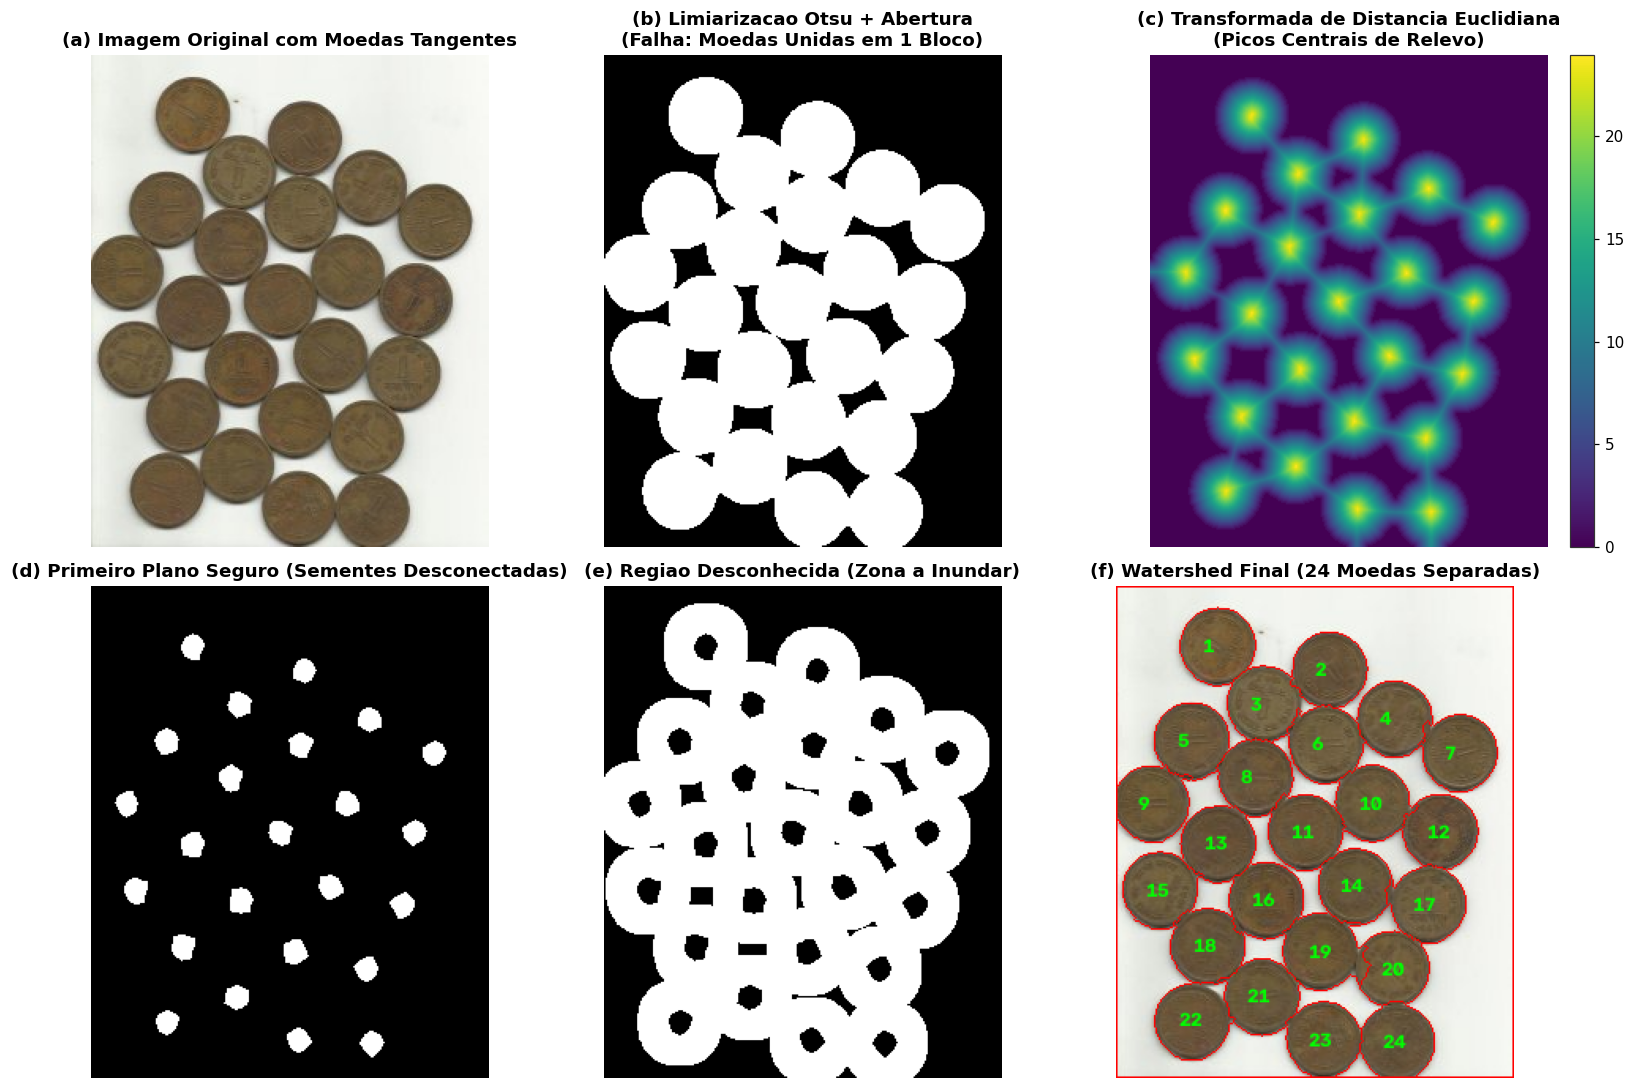

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("(a) Imagem Original com Moedas Tangentes", fontweight='bold')
axes[0, 0].axis("off")

axes[0, 1].imshow(opening, cmap="gray")
axes[0, 1].set_title("(b) Limiarizacao Otsu + Abertura\n(Falha: Moedas Unidas em 1 Bloco)", fontweight='bold')
axes[0, 1].axis("off")

im_dist_plot = axes[0, 2].imshow(dist_transform, cmap="viridis")
axes[0, 2].set_title("(c) Transformada de Distancia Euclidiana\n(Picos Centrais de Relevo)", fontweight='bold')
axes[0, 2].axis("off")
plt.colorbar(im_dist_plot, ax=axes[0, 2], fraction=0.046, pad=0.04)

axes[1, 0].imshow(sure_fg, cmap="gray")
axes[1, 0].set_title("(d) Primeiro Plano Seguro (Sementes Desconectadas)", fontweight='bold')
axes[1, 0].axis("off")

axes[1, 1].imshow(unknown, cmap="gray")
axes[1, 1].set_title("(e) Regiao Desconhecida (Zona a Inundar)", fontweight='bold')
axes[1, 1].axis("off")

axes[1, 2].imshow(img_metrologia)
axes[1, 2].set_title(f"(f) Watershed Final ({len(rotulos_validos)} Moedas Separadas)", fontweight='bold')
axes[1, 2].axis("off")

plt.tight_layout()
out_fig = os.path.join("resultados", "watershed_pipeline_completo.png")
plt.savefig(out_fig, dpi=180, bbox_inches='tight')
print("Figura salva em:", out_fig)
plt.show()
